# 4 - Compressed sensing with a generative prior


> Part of **[Compressed Sensing using Generative Models](../README.md)**.
> Run `pip install -e .` from the repository root first; every notebook imports
> the `csgm` package rather than redefining the model and recovery code inline.


This is the core experiment. We observe only $m \ll n$ noisy linear
measurements of an unknown digit,

$$y = A x^* + \eta, \qquad A \in \mathbb{R}^{m \times n},\; \eta \sim \mathcal{N}(0, \sigma^2 I),$$

and reconstruct $x^*$ by searching the **range of a trained generator** instead
of the set of sparse vectors:

$$\hat z = \arg\min_z \; \|A G(z) - y\|_2^2 + \lambda \|z\|_2^2, \qquad \hat x = G(\hat z).$$

The objective is non-convex - $G$ is a deep network - so it is minimised with
Adam from several random initialisations, keeping the restart with the smallest
residual. Bora et al. (2017) show that if $G$ is $L$-Lipschitz, roughly
$O(k \log L)$ measurements suffice for an $\ell_2/\ell_2$ recovery guarantee: the
cost scales with the **latent** dimension, not the ambient one.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from csgm.baselines import lasso_recover
from csgm.config import DEFAULT_SEED, N_PIXELS
from csgm.data import load_mnist
from csgm.measurements import gaussian_measurement_matrix, measure
from csgm.metrics import per_pixel_l2, psnr
from csgm.models import load_generator
from csgm.recovery import RecoveryConfig, recover
from csgm.viz import plot_error_curves, show_images

## 4.1 A generator and a target

target digit: 7


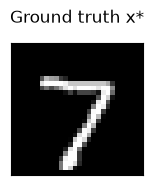

In [2]:
latent_dim = 20
# The VAE decoder is used for the walkthrough: it inverts in a fraction of the
# time a DCGAN generator takes, and the DCGAN checkpoints in this repository were
# trained before the test split was held out, so they are not a clean prior to
# demonstrate on. Both are compared properly in section 4.4, which reads results
# produced by the benchmark script.
G = load_generator("vae", latent_dim)

(_, _), (x_test, y_test) = load_mnist(flatten=True)
x_star = x_test[0]
print("target digit:", y_test[0])

show_images(np.stack([x_star]), ncols=1, suptitle="Ground truth x*");


## 4.2 One reconstruction, step by step

With $m = 100$ we keep 13% of the pixels' worth of information. Note that $z$ is
initialised from $\mathcal{N}(0, I)$ - the same prior the generator was trained
under. Starting much closer to the origin would bias the search towards the blurry
centre of the latent space, which is why the initialisation matches the prior
rather than being shrunk towards zero.

In [3]:
m = 100
A = gaussian_measurement_matrix(m, N_PIXELS, seed=DEFAULT_SEED)
y = measure(x_star, A, noise_std=0.1 / np.sqrt(m), seed=DEFAULT_SEED)
print("y has", y.shape[1], "numbers describing a", N_PIXELS, "pixel image")

result = recover(
    G, y, A, latent_dim,
    RecoveryConfig(steps=1000, restarts=10, learning_rate=0.01, log_every=200),
    track_history=True,
)
print(f"per-pixel error {per_pixel_l2(result.x_hat, x_star)[0]:.4f}"
      f" | PSNR {psnr(result.x_hat, x_star)[0]:.2f} dB")

y has 100 numbers describing a 784 pixel image


  step     0 | mean objective 95.17564


  step   200 | mean objective 30.49002


  step   400 | mean objective 20.13552


  step   600 | mean objective 14.55437


  step   800 | mean objective 11.45428


per-pixel error 0.0018 | PSNR 27.46 dB


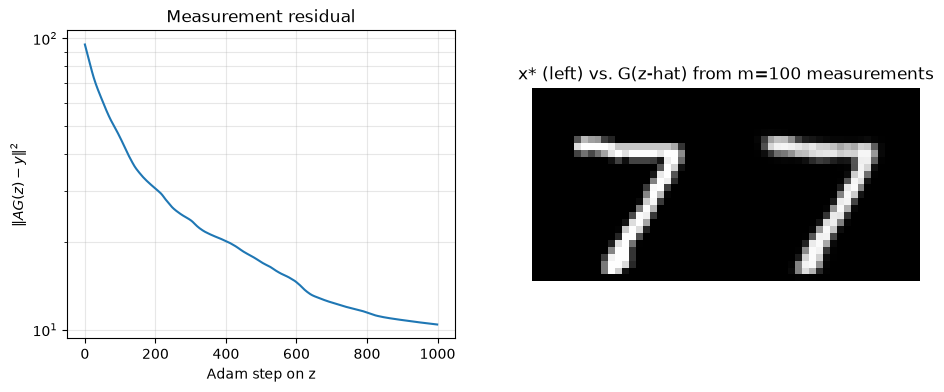

In [4]:
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.plot(result.history)
left.set_yscale("log")
left.set_xlabel("Adam step on z")
left.set_ylabel(r"$\|A G(z) - y\|^2$")
left.set_title("Measurement residual")
left.grid(alpha=0.3, which="both")

right.imshow(
    np.concatenate([x_star.reshape(28, 28), result.x_hat[0].reshape(28, 28)], axis=1),
    cmap="gray", vmin=0, vmax=1,
)
right.set_title(f"x* (left) vs. G(z-hat) from m={m} measurements")
right.axis("off");

The residual falls by roughly a factor of eight over the first few hundred
steps and then flattens: what remains is the **representation error**, the
distance between $x^*$ and the closest point in the range of $G$. No amount of
extra optimisation removes it, only a better generator does. This is the term
that sets the error floor in the next section.


## 4.3 Why random restarts matter

The objective is non-convex, so different initialisations land in different
local minima. The spread below is the reason the recovery loop keeps the best of
ten rather than trusting a single run.

best/worst residual ratio: 0.6234077


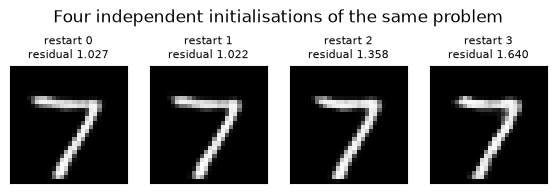

In [5]:
residuals, images = [], []
for seed in range(4):
    single = recover(G, y, A, latent_dim, RecoveryConfig(steps=1000, restarts=1, seed=seed))
    residuals.append(single.residual[0])
    images.append(single.x_hat[0])

show_images(
    np.stack(images),
    [f"restart {i}\nresidual {r:.3f}" for i, r in enumerate(residuals)],
    ncols=4,
    suptitle="Four independent initialisations of the same problem",
)
print("best/worst residual ratio:", min(residuals) / max(residuals))

## 4.4 Sweeping the measurement budget

Now the comparison the whole project is about: the same images, the same
measurement matrices, five learned priors and two sparse baselines, across ten
measurement budgets.

Running that sweep here would take hours, so it lives in a script that writes
its results to disk:

```bash
python scripts/run_benchmark.py --n-images 10 --steps 1000 --restarts 10 --l2-penalty 0.1
```

This section reads what that run produced. Every number below therefore comes
from the same seeded, reproducible experiment as the figures in the README.

In [6]:
import pandas as pd

from csgm.config import RESULTS_DIR

benchmark = pd.read_csv(RESULTS_DIR / "benchmark.csv")
print(f"{benchmark['image'].nunique()} images x {benchmark['m'].nunique()} budgets "
      f"x {benchmark['method'].nunique()} methods = {len(benchmark)} reconstructions")

mean_error = benchmark.pivot_table(index="m", columns="method", values="per_pixel_error")
mean_error

10 images x 10 budgets x 7 methods = 700 reconstructions


method,dcgan-20,dcgan-30,fcvae-20,lasso,lasso-dct,vae-20,vae-30
m,,,,,,,
10,0.098896,0.073113,0.067995,0.121653,0.103207,0.077815,0.075515
25,0.057095,0.045923,0.027607,0.118905,0.098601,0.028823,0.019378
50,0.042669,0.034571,0.011755,0.117105,0.083486,0.015489,0.019078
75,0.024501,0.031800,0.008428,0.112708,0.071013,0.008773,0.009149
100,0.013586,0.029442,0.008292,0.104551,0.062844,0.008270,0.007748
200,0.010567,0.023282,0.007507,0.082749,0.032468,0.007921,0.007228
300,0.010504,0.024941,0.007171,0.040762,0.020169,0.007600,0.007141
400,0.010050,0.022917,0.007246,0.010659,0.011490,0.007561,0.007031
500,0.009360,0.023716,0.007234,0.000799,0.006415,0.007630,0.007101


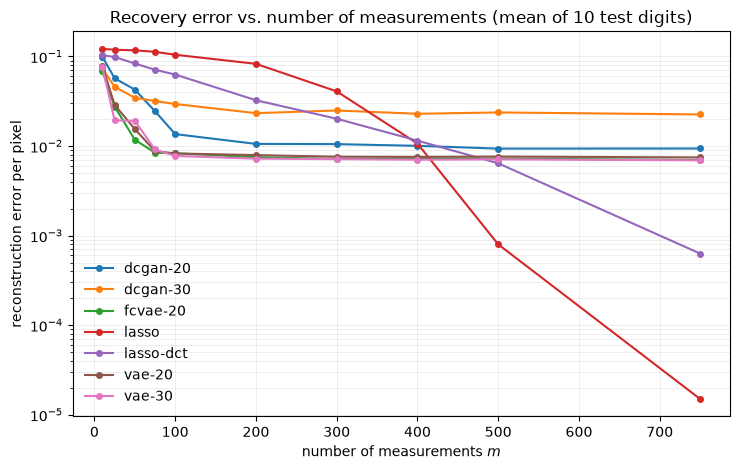

In [7]:
plot_error_curves(
    {method: (column.index, column.to_numpy()) for method, column in mean_error.items()},
    title="Recovery error vs. number of measurements (mean of 10 test digits)",
);

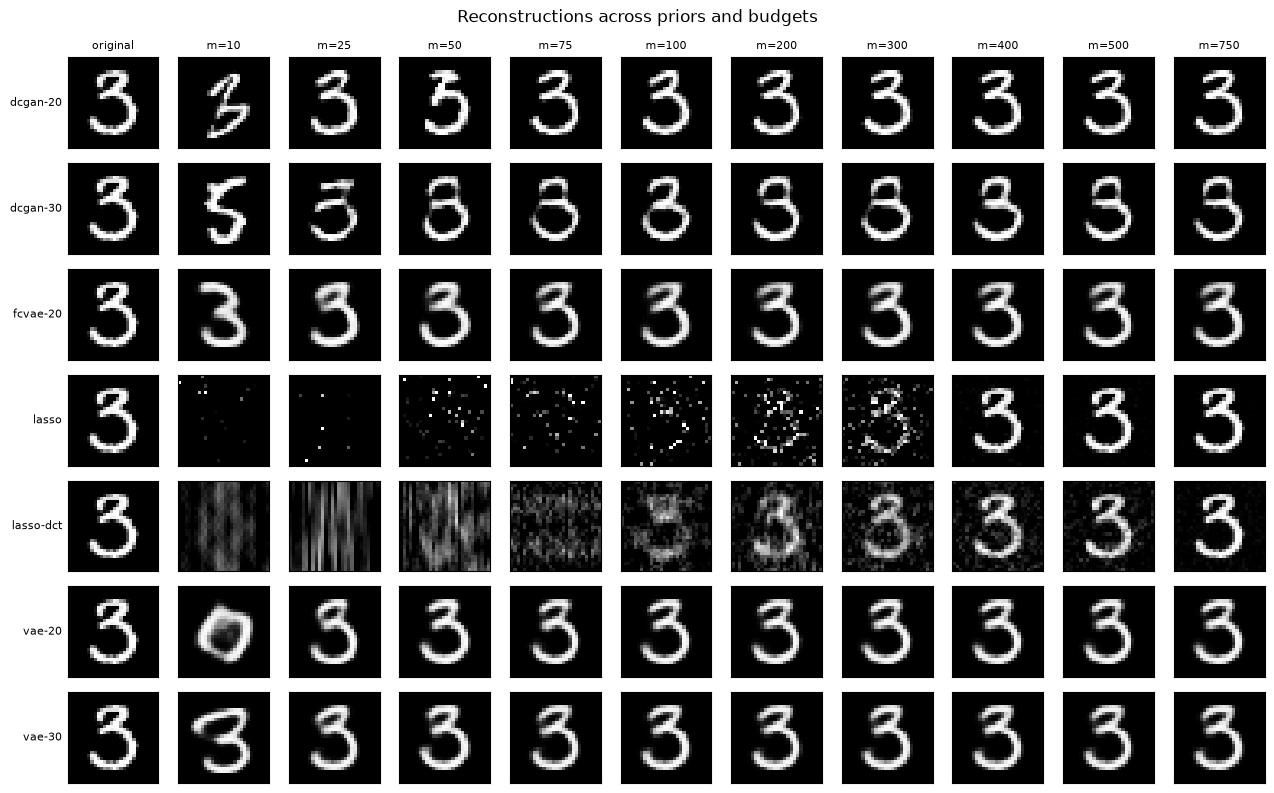

In [8]:
with np.load(RESULTS_DIR / "reconstructions.npz") as archive:
    recons = dict(archive)

methods = list(mean_error.columns)
m_values = sorted(benchmark["m"].unique())
digit = 0

fig, axes = plt.subplots(len(methods), len(m_values) + 1, figsize=(1.05 * len(m_values) + 2.4, 1.05 * len(methods) + 0.7))
for row, method in enumerate(methods):
    axes[row][0].imshow(recons["ground_truth"][digit].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    axes[row][0].set_ylabel(method, fontsize=8, rotation=0, ha="right", va="center")
    if row == 0:
        axes[row][0].set_title("original", fontsize=8)
    for col, m in enumerate(m_values, start=1):
        axes[row][col].imshow(recons[f"{method}__m{m}"][digit].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        if row == 0:
            axes[row][col].set_title(f"m={m}", fontsize=8)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
fig.suptitle("Reconstructions across priors and budgets")
fig.tight_layout();

## 4.5 What the curves say

**The learned priors win where measurements are scarce.** At $m = 25$ the best
prior reaches a per-pixel error of 0.0194 against 0.0986 for Lasso in the DCT
basis, 5.1 times lower, at a budget where neither baseline returns anything
recognisable. The ratio against the pixel basis is 6.1, but that one deserves a
caveat: predicting a blank image scores 0.1178 on these digits, and the pixel
baseline is at or above that level at 10 and 25 measurements, so it is not
reconstructing anything there and a ratio against it means little.

**Sample efficiency.** Either baseline needs 400 measurements to reach about
0.011, and all three VAE priors get there with **75**. That is a **5.3x** saving,
and it is the same figure against both baselines, so the headline does not depend
on which one is taken as the reference. It sits at the lower end of the 5 to 10x
range the paper reports.

**Two baselines, because they disagree.** The paper runs Lasso on MNIST in the
pixel basis, since digits are mostly background. The DCT basis is what the same
authors use for natural images. The DCT basis is the better of the two from 10 to
300 measurements; the pixel basis from 400 up, where it becomes almost exact.

**The priors stop improving.** Past roughly 200 measurements the generative
curves go flat. Averaged from $m = 300$ up the floors are 0.0070 for our
convolutional VAE at $k = 30$, 0.0072 for the paper architecture, 0.0076 for our
$k = 20$, and 0.0098 and 0.0235 for the DCGANs. That floor is the representation
error: the distance from a real digit to the range of $G$, which no measurement
budget and no amount of optimisation can remove. Lasso has no such ceiling, so
from $m = 500$ both baselines overtake every prior, and at $m = 750$ the pixel one
recovers the digits almost exactly. The reference paper predicts this reversal
and states that it takes more than 500 measurements.

**The three VAE priors cannot be told apart.** Comparing the paper's fully
connected network, our convolutional $k = 20$ and our convolutional $k = 30$ with
a paired Wilcoxon test at each budget, corrected across budgets, not one
comparison reaches significance: every corrected p-value is 1. Their floors span
0.0006, which ten images are not enough to separate. Neither the architecture nor
the latent dimension can be ranked from this experiment, and the ordering visible
in the table above is noise.

**The DCGAN is the least accurate prior and by far the most expensive**, about
102 times the cost of the paper's decoder per reconstruction, so on this dataset
there is no accuracy-for-cost trade-off to make. Its two columns also rest on
checkpoints that were trained before the test split was held out, so they are
optimistic by an unknown amount; that limitation is recorded in the README.

The practical reading: a learned prior is the right choice exactly when
measurements are the scarce resource, which is the situation compressed sensing
exists for. It is the wrong choice when measurements are plentiful, and on MNIST
that point arrives well before the signal dimension is reached.

---
See [`results/`](../results) for the full tables, including
[`results/significance.md`](../results/significance.md) for the paired tests, and
[the report](../docs/report) for the write-up.
